# Autoregressive (AR) Model

In [ ]:
!mkdir drive/MyDrive/Datasets

mkdir: cannot create directory ‘drive/MyDrive/Datasets’: File exists


In [ ]:
import pandas as pd
# df=pd.read_csv("Weather_data.csv")
# df.to_csv("drive/MyDrive/Datasets/Weather_data.csv",index=False)

In [ ]:
df=pd.read_csv("drive/MyDrive/Datasets/Weather_data.csv")

In [ ]:
df['Date']=pd.to_datetime(df['Date'])
df.set_index('Date',inplace=True)

In [ ]:
df.isnull().sum()

,0
Temperature,0


In [ ]:
df.head()

,Temperature
Date,
2017-01-01,15.913043
2017-01-02,18.500000
2017-01-03,17.111111
2017-01-04,18.700000
2017-01-05,18.388889


In [ ]:
# staionary tests
from statsmodels.tsa.stattools import adfuller
adfuller(df['Temperature'])

(np.float64(-1.096474275875619),
 np.float64(0.7164758731775932),
 0,
 113,
 {'1%': np.float64(-3.489589552580676),
  '5%': np.float64(-2.887477210140433),
  '10%': np.float64(-2.580604145195395)},
 np.float64(386.6781886302757))

In [ ]:
# conclusion -> data is not stationary

In [ ]:
# Since the ADF p‑value is above 0.05 the series is non‑stationary. We take a first difference to remove trends and achieve stationarity
df_diff = df[["Temperature"]].diff().dropna()

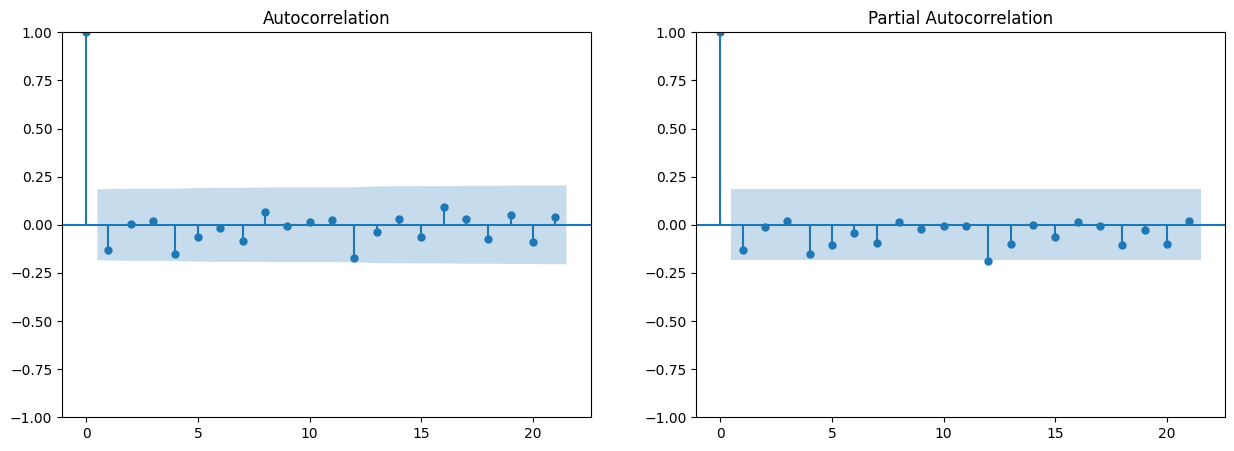

In [ ]:
# acf and pacf plot
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

fig,ax=plt.subplots(1,2,figsize=(15,5))
plot_acf(df_diff,ax=ax[0])
plot_pacf(df_diff,ax=ax[1])
plt.show()

In [ ]:
train_df=df_diff.iloc[:int(len(df)*0.8),:]
test_df=df_diff.iloc[int(len(df)*0.8):,:]

<img src="https://i.postimg.cc/853YG9wf/image.png">
<a href="https://www.geeksforgeeks.org/data-analysis/autoregressive-ar-model-for-time-series-forecasting/" >Read full article here</a>

### Weights can be calculated using ols
###PACF is used to determine the order p of the AR model. It measures the correlation between observations at different lags, excluding the influence of intermediate lags.

In [ ]:
from statsmodels.tsa.ar_model import AutoReg
model = AutoReg(train_df['Temperature'], lags=13)
model_fit = model.fit()
print(model_fit.summary())

                            AutoReg Model Results                             
Dep. Variable:            Temperature   No. Observations:                   91
Model:                    AutoReg(13)   Log Likelihood                -148.173
Method:               Conditional MLE   S.D. of innovations              1.617
Date:                Tue, 04 Nov 2025   AIC                            326.347
Time:                        07:56:45   BIC                            361.697
Sample:                    01-15-2017   HQIC                           340.498
                         - 04-02-2017                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.4284      0.209      2.049      0.040       0.019       0.838
Temperature.L1     -0.1691      0.113     -1.500      0.134      -0.390       0.052
Temperature.L2     -0.0866      

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [ ]:
# start =13 because lag=13
pred_train=model_fit.predict(start=train_df.index[13],end=train_df.index[-1],dynamic=False)
pred_test=model_fit.predict(start=test_df.index[0],end=test_df.index[-1],dynamic=False)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/deterministic.py:308: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  fcast_index = self._extend_index(index, steps, forecast_index)


In [ ]:
pred_train

,0
2017-01-15,0.778115
2017-01-16,0.136620
2017-01-17,-0.060956
2017-01-18,1.000677
2017-01-19,0.272389
...,...
2017-03-29,0.271856
2017-03-30,-0.841051
2017-03-31,-0.014125
2017-04-01,0.489308


In [ ]:
from sklearn.metrics import mean_squared_error
print("Training_error = ",mean_squared_error(train_df.iloc[13:,].values,pred_train.values))
print("Testing_error = ",mean_squared_error(test_df.values,pred_test.values))

Training_error =  2.6154560088196113
Testing_error =  1.7721618758949786


In [ ]:
# actual predictions
last_train_value=df.iloc[int(len(df)*0.8),0]
pred_test.cumsum()+last_train_value

,0
2017-04-03,30.040140
2017-04-04,29.634252
2017-04-05,29.904800
2017-04-06,30.889347
2017-04-07,30.896873
2017-04-08,31.100224
2017-04-09,31.254321
2017-04-10,31.334820
2017-04-11,31.859554
2017-04-12,31.836066


# Moving Average (MA) model
## Basic idea - "Today depends on yesterday's shock/error."
<img src="https://i.postimg.cc/wvHtBLYs/image.png">
<img src="https://i.postimg.cc/ZK0LZtcY/image.png">
<img src="https://i.postimg.cc/nVdh76tK/image.png">

<a href="https://www.geeksforgeeks.org/machine-learning/understanding-the-moving-average-ma-in-time-series-data/">Read full article here</a>
###AR and MA and ARMA ANd ARIMA models all are implemented using arima by changing hyperparameters
##ACF is used to determine the order q of the MA model. It measures the correlation between observations at different lags.
**for arima -> set p=0 and d=0 eg set order=(0,0,q)**

In [ ]:
from statsmodels.tsa.arima.model import ARIMA
model = ARIMA(train_df['Temperature'], order=(0,0,13))
model_fit = model.fit()
print(model_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  

                               SARIMAX Results                                
Dep. Variable:            Temperature   No. Observations:                   91
Model:                ARIMA(0, 0, 13)   Log Likelihood                -174.866
Date:                Tue, 04 Nov 2025   AIC                            379.733
Time:                        07:56:52   BIC                            417.396
Sample:                    01-02-2017   HQIC                           394.927
                         - 04-02-2017                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1482      0.063      2.361      0.018       0.025       0.271
ma.L1         -0.2143      3.104     -0.069      0.945      -6.297       5.869
ma.L2         -0.0340      2.455     -0.014      0.9

In [ ]:
from sklearn.metrics import mean_squared_error
pred_train=model_fit.predict(start=train_df.index[13],end=train_df.index[-1],dynamic=False)
pred_test=model_fit.predict(start=test_df.index[0],end=test_df.index[-1],dynamic=False)
print("Training_error = ",mean_squared_error(train_df.iloc[13:,].values,pred_train.values))
print("Testing_error = ",mean_squared_error(test_df.values,pred_test.values))

Training_error =  2.6206990923633677
Testing_error =  1.8024393341162115


In [ ]:
# predicting
last_train_value=df.iloc[int(len(df)*0.8),0]
pred_test.cumsum()+last_train_value

,predicted_mean
2017-04-03,29.275604
2017-04-04,28.527664
2017-04-05,28.401671
2017-04-06,28.728017
2017-04-07,28.508785
2017-04-08,28.282243
2017-04-09,28.046490
2017-04-10,28.098827
2017-04-11,28.372132
2017-04-12,28.202663


# ARMA model
<img src="https://i.postimg.cc/qqSc1rRf/image.png">
<img src="https://i.postimg.cc/0QrJF4h9/image.png">

### implemented using arima model by setting d=0

In [ ]:
from statsmodels.tsa.arima.model import ARIMA
model = ARIMA(train_df['Temperature'], order=(13,0,13))
model_fit = model.fit()
print(model_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using

                               SARIMAX Results                                
Dep. Variable:            Temperature   No. Observations:                   91
Model:               ARIMA(13, 0, 13)   Log Likelihood                -168.799
Date:                Tue, 04 Nov 2025   AIC                            393.599
Time:                        07:57:09   BIC                            463.903
Sample:                    01-02-2017   HQIC                           421.962
                         - 04-02-2017                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1456      0.085      1.721      0.085      -0.020       0.311
ar.L1         -0.5432      0.971     -0.560      0.576      -2.446       1.359
ar.L2         -0.0755      0.686     -0.110      0.9

In [ ]:
from sklearn.metrics import mean_squared_error
pred_train=model_fit.predict(start=train_df.index[13],end=train_df.index[-1],dynamic=False)
pred_test=model_fit.predict(start=test_df.index[0],end=test_df.index[-1],dynamic=False)
print("Training_error = ",mean_squared_error(train_df.iloc[13:,].values,pred_train.values))
print("Testing_error = ",mean_squared_error(test_df.values,pred_test.values))

Training_error =  2.2474688082203533
Testing_error =  3.0820589242184413


#ARIMA model
<a href="https://www.geeksforgeeks.org/data-science/model-selection-for-arima/">Read full article here</a>

<img src="https://i.postimg.cc/QxYF2Dc2/image.png">
<img src="https://i.postimg.cc/Kv0TmBhC/image.png">

In [ ]:
train_df=df.iloc[:int(len(df)*0.8)]
test_df=df.iloc[int(len(df)*0.8):]

In [ ]:
from statsmodels.tsa.arima.model import ARIMA
model = ARIMA(train_df['Temperature'], order=(13,1,13))
model_fit = model.fit()
print(model_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using

                               SARIMAX Results                                
Dep. Variable:            Temperature   No. Observations:                   91
Model:               ARIMA(13, 1, 13)   Log Likelihood                -169.316
Date:                Mon, 03 Nov 2025   AIC                            392.632
Time:                        08:37:53   BIC                            460.127
Sample:                    01-01-2017   HQIC                           419.850
                         - 04-01-2017                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5028      0.932     -0.539      0.590      -2.329       1.324
ar.L2          0.2480      0.629      0.394      0.693      -0.985       1.481
ar.L3          0.0720      0.456      0.158      0.8

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:
from sklearn.metrics import mean_squared_error
pred_train=model_fit.predict(start=train_df.index[13],end=train_df.index[-1],dynamic=False)
pred_test=model_fit.predict(start=test_df.index[0],end=test_df.index[-1],dynamic=False)
print("Training_error = ",mean_squared_error(train_df.iloc[13:,].values,pred_train.values))
print("Testing_error = ",mean_squared_error(test_df.values,pred_test.values))

Training_error =  2.3852156570232332
Testing_error =  7.01196561063344


In [ ]:
pred_test

,predicted_mean
2017-04-02,29.976269
2017-04-03,28.931257
2017-04-04,28.142521
2017-04-05,28.234629
2017-04-06,29.273992
2017-04-07,30.410593
2017-04-08,30.425622
2017-04-09,29.530915
2017-04-10,28.532818
2017-04-11,29.261931


# SARIMA
Seasonality = Same Season → Fixed & predictable<br>
Cycle = Economics Cycle → Irregular & unpredictable
# SARIMA Model Equation Explanation

## Introduction

SARIMA stands for **Seasonal AutoRegressive Integrated Moving Average**.  
It extends ARIMA by adding **seasonal components** to handle repeating patterns.

Model notation:

$$
SARIMA(p, d, q)(P, D, Q)_s
$$

Where:

- \( p \) = non-seasonal AR order  
- \( d \) = non-seasonal differencing  
- \( q \) = non-seasonal MA order  
- \( P \) = seasonal AR order  
- \( D \) = seasonal differencing  
- \( Q \) = seasonal MA order  
- \( s \) = seasonal period (e.g., 12 for monthly data)

---

## Lag Operator

A lag operator shifts the time series:

$$
L y_t = y_{t-1}, \quad L^2 y_t = y_{t-2}
$$

Seasonal lag example (\(s = 12\)):

$$
L^{12}y_t = y_{t-12}
$$

---

## Differencing

### Non-seasonal differencing
Removes trend:

$$
(1 - L)^d y_t
$$

### Seasonal differencing
Removes repeating seasonal pattern:

$$
(1 - L^s)^D y_t
$$

---

## AR Components

### Non-seasonal AR(p)
$$
\phi_p(L) = 1 - \phi_1 L - \phi_2 L^2 - \cdots - \phi_p L^p
$$

### Seasonal AR(P)
$$
\Phi_P(L^s) = 1 - \Phi_1 L^s - \Phi_2 L^{2s} - \cdots - \Phi_P L^{Ps}
$$

---

## MA Components

### Non-seasonal MA(q)
$$
\theta_q(L) = 1 + \theta_1 L + \theta_2 L^2 + \cdots + \theta_q L^q
$$

### Seasonal MA(Q)
$$
\Theta_Q(L^s) = 1 + \Theta_1 L^s + \Theta_2 L^{2s} + \cdots + \Theta_Q L^{Qs}
$$

---

## Full SARIMA Model Equation

Combining AR, MA, differencing, and seasonal components:

$$
\Phi_P(L^s)\,\phi_p(L)\,(1-L)^d\,(1-L^s)^D\,y_t
=
\Theta_Q(L^s)\,\theta_q(L)\,\epsilon_t
$$

Where:

- \( y_t \) = time series value
- \( \epsilon_t \) = error term (white noise)

---

## Intuition

SARIMA applies filters **sequentially**:

| Component | Purpose |
|---|---|
$$(1-L)^d $$ | Remove trend |
$$(1-L^s)^D $$ | Remove seasonality |
$$ \phi_p(L) $$ | AR dependency |
$$ \Phi_P(L^s) $$ | Seasonal AR dependency |
$$ \theta_q(L) $$ | MA error dependency |
$$ \Theta_Q(L^s) $$ | Seasonal MA dependency |

SARIMA = **De‑trend + De‑seasonalize + AR + MA + seasonal AR + seasonal MA**

---

## Summary

SARIMA builds on ARIMA by adding seasonal lag behavior to:
- differencing,
- AR terms,
- MA terms.

This makes it powerful for data with **seasonal cycles**.

### Implemented using sarimax

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [ ]:
model=SARIMAX(train_df['Temperature'],order=(1,1,1),seasonal_order=(13,1,13,12))
model_fit=model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:
from sklearn.metrics import mean_squared_error
pred_train=model_fit.predict(start=train_df.index[13],end=train_df.index[-1],dynamic=False)
pred_test=model_fit.predict(start=test_df.index[0],end=test_df.index[-1],dynamic=False)
print("Training_error = ",mean_squared_error(train_df.iloc[13:,].values,pred_train.values))
print("Testing_error = ",mean_squared_error(test_df.values,pred_test.values))

Training_error =  4.297023318422061
Testing_error =  35.649419534245574


# SARIMAX
<img src="https://i.postimg.cc/Bnh2ZKDN/image.png">
<img src="https://i.postimg.cc/hGgNnNLq/image.png">
<a href="https://www.statsmodels.org/dev/generated/statsmodels.tsa.statespace.sarimax.SARIMAX.html">Read documentation here</a>

# VAR , VMA , VARMA  Model
**Vector Autoregression (VAR) is a multivariate extension of autoregression (AR) models. While traditional AR models analyze the relationship between a single variable and its lagged values, VAR models consider multiple variables simultaneously. In a VAR model, each variable is regressed on its own lagged values as well as lagged values of other variables in the system.**
<img src="https://i.postimg.cc/rs60Mgty/image.png">
<img src="https://i.postimg.cc/yx6SxjTg/image.png">

# Similarily VMA and VARMA are also extension of MA and ARMA model

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller

In [3]:
# Sample data generation
np.random.seed(0)
dates = pd.date_range(start='2024-01-01', periods=100)
data = pd.DataFrame(np.random.randn(100, 3), index=dates, columns=['A', 'B', 'C'])

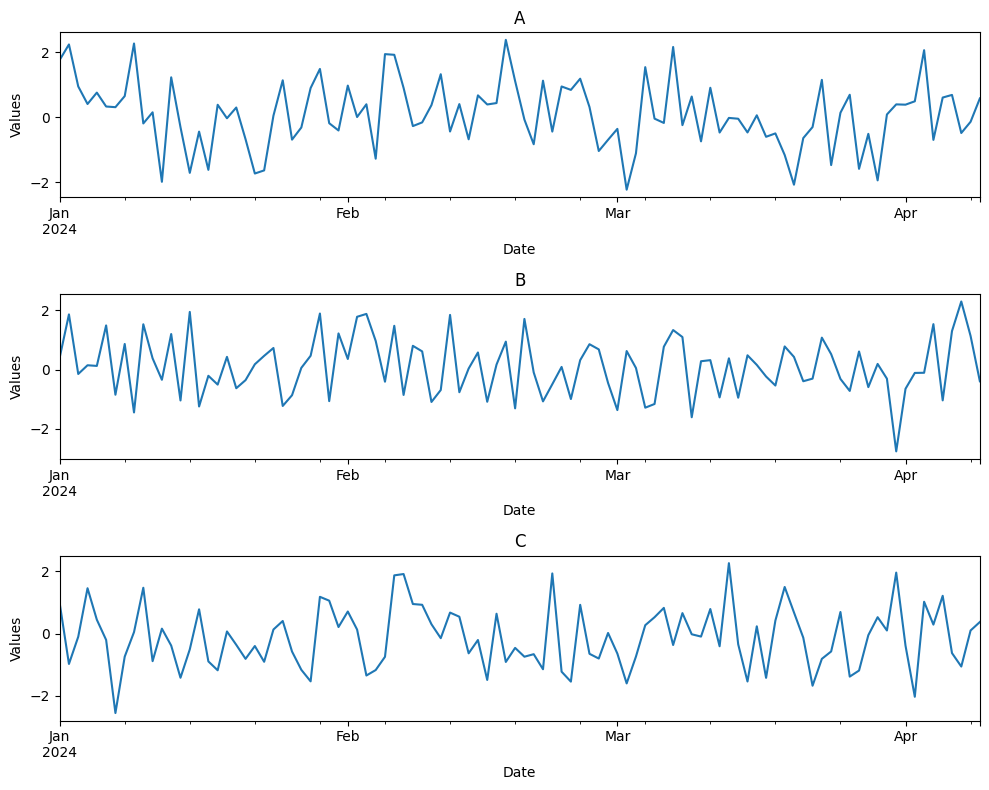

In [4]:
# Function to plot time series
def plot_series(data):
    fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(10, 8))
    for i, col in enumerate(data.columns):
        data[col].plot(ax=axes[i], title=col)
        axes[i].set_ylabel('Values')
        axes[i].set_xlabel('Date')
    plt.tight_layout()
    plt.show()

plot_series(data)

In [5]:
# Check stationarity of time series using ADF test
def check_stationarity(timeseries):
    result = adfuller(timeseries)
    print('ADF Statistic:', result[0])
    print('p-value:', result[1])
    print('Critical Values:')
    for key, value in result[4].items():
        print('\t%s: %.3f' % (key, value))

In [6]:
for i in data.columns:
  check_stationarity(data[i])

ADF Statistic: -8.43759993424834
p-value: 1.7990274249398063e-13
Critical Values:
	1%: -3.498
	5%: -2.891
	10%: -2.583
ADF Statistic: -11.229664527662438
p-value: 1.9214648218450937e-20
Critical Values:
	1%: -3.498
	5%: -2.891
	10%: -2.583
ADF Statistic: -9.028783852793346
p-value: 5.516998045646418e-15
Critical Values:
	1%: -3.498
	5%: -2.891
	10%: -2.583


In [16]:
model=VAR(data)
lags=2
results=model.fit(lags)

In [17]:
results.k_ar

2

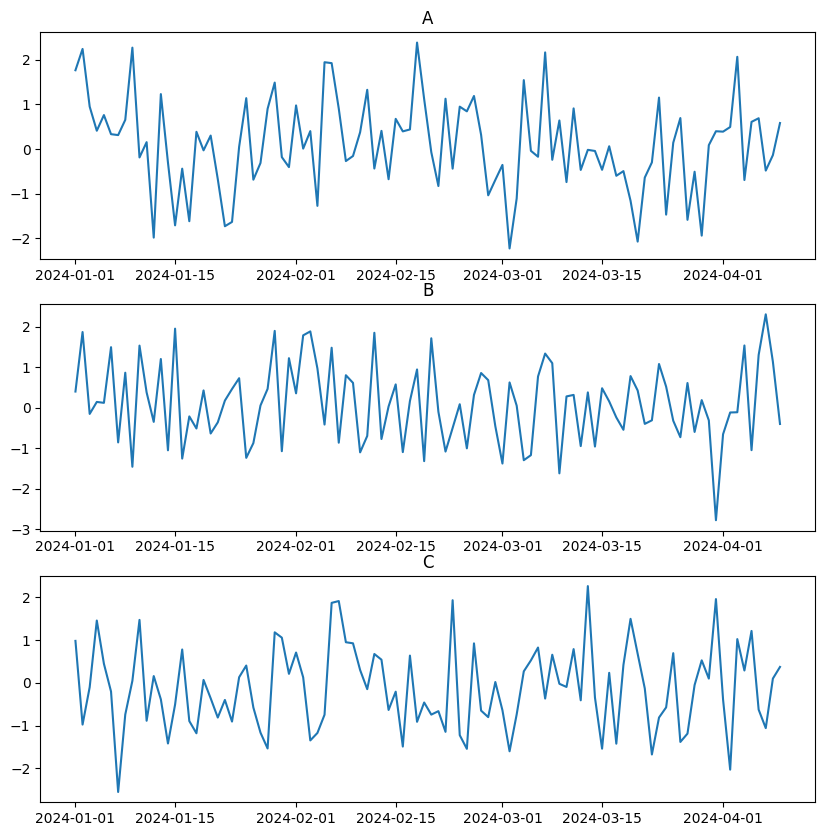

In [18]:
# Plotting input time series:
fig=results.plot()
fig.show()

In [20]:
# In results.forecast(data.values[-lags:], steps=2), the steps argument specifies how many future time points you want to predict.
forecast=results.forecast(data.values[-lags:],steps=10)

In [11]:
forecast_index = pd.date_range(start='2024-04-11', periods=10)
forecast_data = pd.DataFrame(forecast, index=forecast_index, columns=data.columns)
forecast_data

,A,B,C
2024-04-11,-0.076867,0.097510,0.015168
2024-04-12,0.043928,0.201317,-0.207337
2024-04-13,0.034764,0.043131,-0.185967
2024-04-14,0.046291,0.080103,-0.117413
2024-04-15,0.063728,0.065625,-0.130900
2024-04-16,0.051763,0.078522,-0.137288
2024-04-17,0.055968,0.079489,-0.136277
2024-04-18,0.055546,0.076214,-0.134820
2024-04-19,0.055141,0.077582,-0.134238
2024-04-20,0.055314,0.077245,-0.134883


# VARMAX
<img src="https://i.postimg.cc/8CH9LKmD/image.png">
<img src="https://i.postimg.cc/vmFYXLSf/image.png">
<img src="https://i.postimg.cc/PJ9sJTgm/image.png">

# The VARMAX class in statsmodels is used for applying VAR, VMA, and VARMA  and VARMAX models
<a href="https://www.statsmodels.org/dev/examples/notebooks/generated/statespace_varmax.html">VAR,VMA,VARMA here</a>
# above shown is also a way for var model but this is general

In [12]:
data.head()

,A,B,C
2024-01-01,1.764052,0.400157,0.978738
2024-01-02,2.240893,1.867558,-0.977278
2024-01-03,0.950088,-0.151357,-0.103219
2024-01-04,0.410599,0.144044,1.454274
2024-01-05,0.761038,0.121675,0.443863


In [25]:
from statsmodels.tsa.statespace.varmax import VARMAX

# order is -> p,q for ar and ma
model=VARMAX(endog=data[['A','B']],exog=data[['C']],order=(2,1))
results=model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/varmax.py:160: EstimationWarning: Estimation of VARMA(p,q) models is not generically robust, due especially to identification issues.
  warn('Estimation of VARMA(p,q) models is not generically robust,'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [29]:
# for predicting exog feature is required
results.predict(exog=data[['C']].values, start=0, end=20)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:1785: ValueWarning: Exogenous array provided, but additional data is not required. `exog` argument ignored.
  warnings.warn('Exogenous array provided, but additional data'


,A,B
2024-01-01,0.237746,0.271716
2024-01-02,0.549096,0.449526
2024-01-03,0.867934,0.357427
2024-01-04,0.213109,0.514189
2024-01-05,0.331124,0.584044
2024-01-06,0.429107,0.429461
2024-01-07,0.425755,0.120765
2024-01-08,0.040906,0.534550
2024-01-09,0.507083,0.289974
2024-01-10,0.391704,0.544001
